# Lorenz-63: 3DVar and ExKF comparison

## 1. Overview

This tutorial compares two classical sequential data-assimilation methods on
the chaotic Lorenz-63 model with fully observed, noisy observations:
**3DVar** (a static-gain analysis) and the **extended Kalman filter (ExKF)**
(a dynamically propagated covariance). It follows the representative
notebook specification in `docs/notebook_spec.md`; the paired CLI script is
`examples/scripts/l63_3dvar_exkf.py`.

## 2. Model

The Lorenz-63 model is the three-variable chaotic system

$$
\dot{x} = \sigma (y - x), \qquad
\dot{y} = x (r - z) - y, \qquad
\dot{z} = x y - b z,
$$

with the standard chaotic parameters $\sigma = 10$, $r = 28$, $b = 8/3$
(`da.l63.lorenz63`). The state is $x_n = (x, y, z) \in \mathbb{R}^{3}$.
The discrete forecast map $M$ integrates the system with fourth-order
Runge-Kutta (`da.scheme.rk4`) using time step $\delta t$ over one
assimilation window of $n_{\mathrm{obs}}$ steps, i.e.
$\Delta t = n_{\mathrm{obs}}\, \delta t$:

$$
x_n = M(x_{n-1}) = \Psi_{\delta t}^{n_{\mathrm{obs}}}(x_{n-1}).
$$

## 3. Observation

The full state is observed with additive Gaussian noise every assimilation
window:

$$
y_n = H x_n + \varepsilon_n, \qquad
H = I_3, \qquad
\varepsilon_n \sim N(0, R), \quad R = r_0^2 I_3 .
$$

The observation-noise scale used for RMSE comparison is
$\sigma_{\mathrm{obs}} = \sqrt{\operatorname{tr}(R)/N_y} = r_0$
(see `docs/notebook_spec.md`).

## 4. DA method

Both methods share the analysis form
$x^a = x^f + K (y - H x^f)$ and differ in the gain $K$.

**3DVar** uses a fixed background covariance $B$:

$$
K = B H^{\mathsf T} (H B H^{\mathsf T} + R)^{-1}.
$$

**ExKF** propagates the covariance through the linearized forecast map
$F_n$ (a finite-difference Jacobian of $M$):

$$
P_n^f = F_n P_{n-1}^a F_n^{\mathsf T}, \qquad
K_n = P_n^f H^{\mathsf T} (H P_n^f H^{\mathsf T} + R)^{-1}, \qquad
P_n^a = (I - K_n H) P_n^f .
$$

**Forecast step (both):** $x_n^f = M(x_{n-1}^a)$.

## 5. Parameters

| Parameter | Symbol | Value |
| --- | --- | --- |
| integration step | $\delta t$ | 0.01 |
| steps per window | $n_{\mathrm{obs}}$ | 5 |
| assimilation cycles | | 400 |
| observation noise variance | $r_0^2$ | 2.0 |
| background covariance (3DVar) | $B$ | $4 I_3$ |
| initial covariance (ExKF) | $P_0$ | $4 I_3$ |
| initial offset | | $(2, -1, 1.5)$ |
| random seed | | 7 |

The script exposes `--cycles`, `--obs-noise-variance`,
`--background-variance`, `--dt`, `--obs-interval`, and `--seed`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from da.l63 import lorenz63
from da.scheme import rk4
from da.exkf import ExKF
from da.var3d import Var3D

def l63_step(x, dt):
    return rk4(lorenz63, 0.0, np.asarray(x), (), dt)


def advance(x, dt, n_steps):
    x = np.asarray(x, dtype=float).copy()
    for _ in range(n_steps):
        x = l63_step(x, dt)
    return x


def rmse(x, truth):
    return float(np.sqrt(np.mean((np.asarray(x) - np.asarray(truth)) ** 2)))


def attractor_ensemble(rng, base, size, spinup=2000, interval=25, pool=1000):
    """Climatological sample from the attractor (cf. examples/scripts/_common.py)."""
    x = advance(base, dt, spinup)
    members = np.empty((pool, np.size(base)))
    for i in range(pool):
        x = advance(x, dt, interval)
        members[i] = x
    return members[rng.choice(pool, size=size, replace=False)]

dt, obs_interval, cycles, seed = 0.01, 5, 400, 7
H = np.eye(3)
R = 2.0 * np.eye(3)
B = 4.0 * np.eye(3)

## 6. Truth and observations

The truth starts from $(1, 1, 1)$ and is observed (all three components)
at the end of every assimilation window.

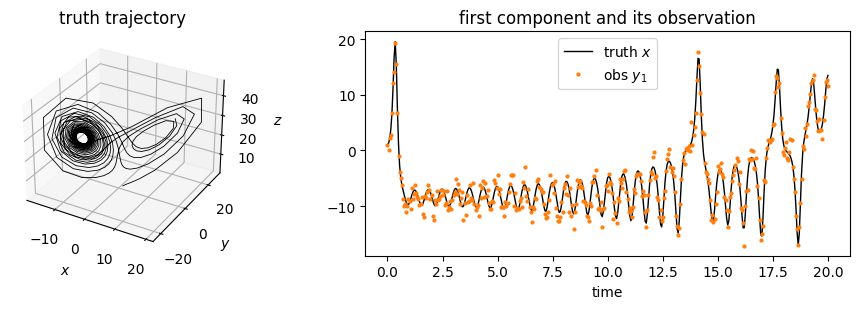

In [2]:
rng = np.random.default_rng(seed)
x = np.array([1.0, 1.0, 1.0])
truth = [x.copy()]
obs = [H @ x + rng.multivariate_normal(np.zeros(3), R)]
for _ in range(cycles):
    x = advance(x, dt, obs_interval)
    truth.append(x.copy())
    obs.append(H @ x + rng.multivariate_normal(np.zeros(3), R))
truth, obs = np.asarray(truth), np.asarray(obs)
t = np.arange(cycles + 1) * dt * obs_interval

fig = plt.figure(figsize=(10, 3.2))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(*truth.T, lw=0.6, color="k")
ax.set_title("truth trajectory")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax = fig.add_subplot(1, 2, 2)
ax.plot(t, truth[:, 0], color="k", lw=1, label="truth $x$")
ax.plot(t, obs[:, 0], ".", color="tab:orange", ms=4, label="obs $y_1$")
ax.set_xlabel("time")
ax.legend()
ax.set_title("first component and its observation")
fig.tight_layout()

## 7. Assimilation results

Both filters start from the same offset initial state. `Var3D` keeps the
gain fixed; `ExKF` updates its covariance every cycle.

In [3]:
x0 = attractor_ensemble(rng, np.array([1.0, 1.0, 1.0]), 1)[0]
var3d = Var3D(lambda x, d: advance(x, d, obs_interval), H, R)
var3d.initialize(x0, B)
exkf = ExKF(lambda x, d: advance(x, d, obs_interval), H, R)
exkf.initialize(x0, B)

var_states, exkf_states = [x0.copy()], [x0.copy()]
var_rmses, exkf_rmses = [rmse(x0, truth[0])], [rmse(x0, truth[0])]
for k in range(1, cycles + 1):
    for filt, states, rmses in ((var3d, var_states, var_rmses), (exkf, exkf_states, exkf_rmses)):
        filt.forecast(dt)
        filt.update(obs[k])
        states.append(filt.x_a.copy())
        rmses.append(rmse(filt.x_a, truth[k]))
var_states, exkf_states = np.asarray(var_states), np.asarray(exkf_states)
var_rmses, exkf_rmses = np.asarray(var_rmses), np.asarray(exkf_rmses)

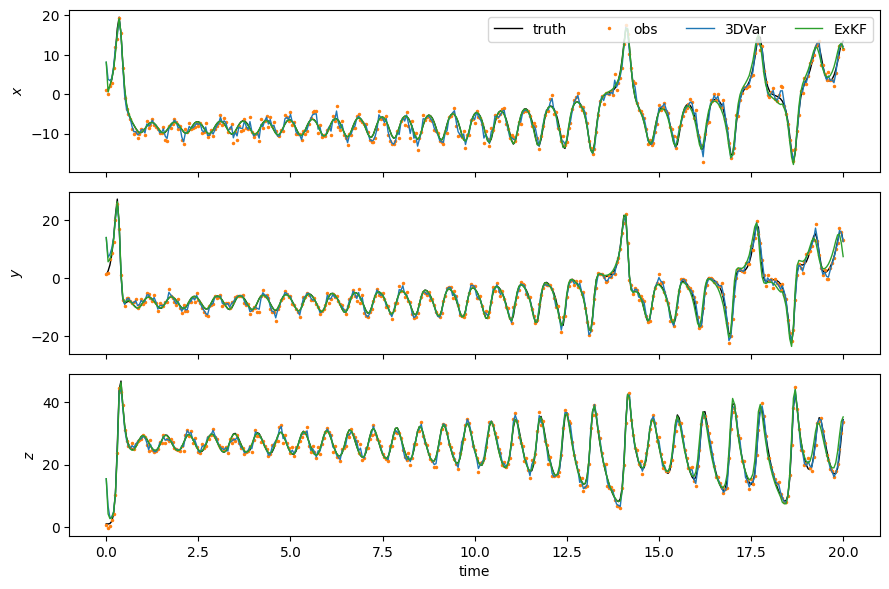

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, truth[:, i], color="k", lw=1, label="truth")
    ax.plot(t, obs[:, i], ".", color="tab:orange", ms=3, label="obs")
    ax.plot(t, var_states[:, i], color="tab:blue", lw=1, label="3DVar")
    ax.plot(t, exkf_states[:, i], color="tab:green", lw=1, label="ExKF")
    ax.set_ylabel(["$x$", "$y$", "$z$"][i])
axes[0].legend(ncol=4, loc="upper right")
axes[-1].set_xlabel("time")
fig.tight_layout()

## 8. RMSE

Analysis RMSE (`docs/notebook_spec.md`):
$\mathrm{RMSE}_n = \sqrt{\tfrac{1}{3}\sum_i (x^a_{n,i} - x_{n,i})^2}$,
compared with the observation-noise scale
$\sigma_{\mathrm{obs}} = \sqrt{\operatorname{tr}(R)/N_y} = \sqrt{2}$.

observation noise scale: 1.414
3DVar mean RMSE (2nd half): 0.909
ExKF  mean RMSE (2nd half): 0.931


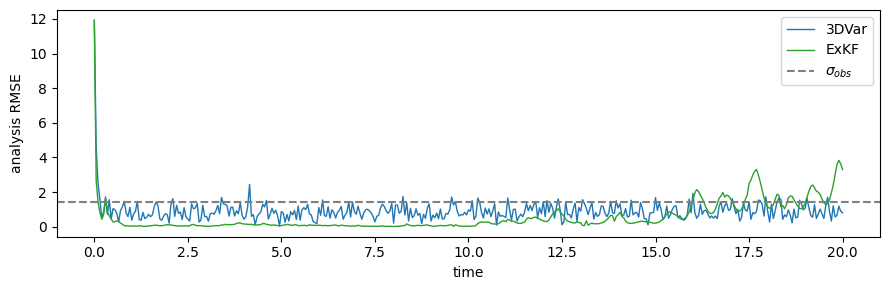

In [5]:
sigma_obs = np.sqrt(np.trace(R) / R.shape[0])
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, var_rmses, color="tab:blue", lw=1, label="3DVar")
ax.plot(t, exkf_rmses, color="tab:green", lw=1, label="ExKF")
ax.axhline(sigma_obs, color="gray", ls="--", label=r"$\sigma_{obs}$")
ax.set_xlabel("time")
ax.set_ylabel("analysis RMSE")
ax.legend()
fig.tight_layout()

half = cycles // 2
print(f"observation noise scale: {sigma_obs:.3f}")
print(f"3DVar mean RMSE (2nd half): {var_rmses[half:].mean():.3f}")
print(f"ExKF  mean RMSE (2nd half): {exkf_rmses[half:].mean():.3f}")

## 9. Summary

Both methods keep the analysis error below the observation-noise scale
$\sigma_{\mathrm{obs}} = \sqrt{2} \approx 1.41$ on average, but neither is
far below it: the static gain of 3DVar cannot adapt to the flow, and the
ExKF linearization struggles during strong transitions between the two
attractor lobes (visible as RMSE spikes). Ensemble methods on the same
setting (see the L63 ETKF tutorial) track the truth noticeably better.